<a href="https://colab.research.google.com/github/Sameera-AU-CSE/Fake-News-and-Rumor-Detection-/blob/main/Fake%20rumor%20collab%20code%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 from google.colab import files; uploaded = files.upload()

Saving indian twitter new dataset.xlsx to indian twitter new dataset.xlsx


In [2]:
import pandas as pd
# Load your Indian Twitter dataset
df = pd.read_excel('indian twitter new dataset.xlsx')  # or .csv

print("📊 INDIAN TWITTER DATASET ANALYSIS")
print("="*50)

# 1. BASIC INFO
print(f"Shape: {df.shape} (rows, columns)")
print(f"Columns: {list(df.columns)}")
print()

# 2. DATA PREVIEW
print("First 3 rows:")
print(df.head(3))
print()

# 3. DATA TYPES & MEMORY
print("Data types:")
print(df.dtypes)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()

# 4. LABEL DISTRIBUTION (if exists)
label_cols = ['label', 'Label', 'is_fake', 'rumor', 'fake', 'verification']
for col in label_cols:
    if col in df.columns:
        print(f"{col} distribution:")
        print(df[col].value_counts())
        print()
        break
else:
    print("No label column found - check column names above")

# 5. MISSING VALUES
print("Missing values:")
print(df.isnull().sum())
print()

# 6. TEXT COLUMNS (likely tweet columns)
text_cols = [col for col in df.columns if 'text' in col.lower() or 'tweet' in col.lower()]
print(f"Text columns found: {text_cols}")
if text_cols:
    print(f"Sample tweet: {df[text_cols[0]].iloc[0]}")

# 7. NUMERICAL FEATURES (retweets, likes, etc.)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns: {num_cols}")

print("\n✅ Dataset structure analyzed!")
print("Copy the column names above - I'll customize preprocessing for your exact dataset.")

📊 INDIAN TWITTER DATASET ANALYSIS
Shape: (26232, 19) (rows, columns)
Columns: ['id', 'Author_Name', 'Fact_Check_Source', 'Source_Type', 'Statement', 'Eng_Trans_Statement', 'News Body', 'Eng_Trans_News_Body', 'Media_Link', 'Publish_Date', 'Fact_Check_Link', 'News_Category', 'Language', 'Region', 'Platform', 'Text', 'Video', 'Image', 'Label']

First 3 rows:
       id         Author_Name Fact_Check_Source Source_Type  \
0  BFNK_1  Shinjinee Majumder          Alt News        IFCN   
1  BFNK_2         Kalim Ahmed          Alt News        IFCN   
2  BFNK_3      Abhishek Kumar          Alt News        IFCN   

                                           Statement  \
0  फ़ैक्ट-चेक: तेलंगाना में एक रिपोर्टर ने गृह मंत...   
1  PM मोदी को UAE का सर्वोच्च नागरिक सम्मान मिलने...   
2  वायरल तस्वीर में सुप्रीम कोर्ट के जज सूर्यकांत...   

                                 Eng_Trans_Statement  \
0  Fact-check: A reporter in Telangana stopped sp...   
1  Share by stating the old video of PM Modi's hi...

In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel('indian twitter new dataset.xlsx')   #  file name/path

# Check shape and missing values
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Optional: see columns after renaming
print("\nColumns:\n", df.columns.tolist())

# Drop columns that are not useful for text classification
drop_cols = ['Media_Link', 'Fact_Check_Link', 'Video', 'Image']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

# Fill missing values for categorical columns
for col in ['Author_Name', 'News_Category', 'Region', 'Language', 'Platform', 'Source_Type', 'Fact_Check_Source']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Fill missing values for date if needed
if 'Publish_Date' in df.columns:
    df['Publish_Date'] = df['Publish_Date'].fillna('Unknown')

# Fill missing values in text columns
for col in ['Statement', 'Eng_Trans_Statement', 'News_Body', 'Eng_Trans_News_Body', 'Text']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Create a single main text column
text_parts = []
for col in ['Eng_Trans_Statement', 'Statement', 'Eng_Trans_News_Body', 'News_Body', 'Text']:
    if col in df.columns:
        text_parts.append(df[col].astype(str))

if text_parts:
    df['combined_text'] = text_parts[0]
    for part in text_parts[1:]:
        df['combined_text'] = df['combined_text'] + ' ' + part
    df['combined_text'] = df['combined_text'].str.strip()

# Remove empty rows in combined text
df = df[df['combined_text'].str.len() > 0].reset_index(drop=True)

# Basic cleanup before stopwords
df['combined_text'] = df['combined_text'].str.lower()
df['combined_text'] = df['combined_text'].str.replace(r'\s+', ' ', regex=True)

# Save cleaned base file
df.to_csv('/indian twitter new cleaned_dataset.csv', index=False)

print("\nFinal shape:", df.shape)
print(df[['combined_text', 'Label']].head())

Shape: (26232, 19)

Missing values:
 id                        0
Author_Name             227
Fact_Check_Source         0
Source_Type               0
Statement                 0
Eng_Trans_Statement       0
News Body               873
Eng_Trans_News_Body     872
Media_Link             1743
Publish_Date            815
Fact_Check_Link        1930
News_Category            16
Language                  0
Region                  707
Platform                  0
Text                      0
Video                     0
Image                     0
Label                     0
dtype: int64

Columns:
 ['id', 'Author_Name', 'Fact_Check_Source', 'Source_Type', 'Statement', 'Eng_Trans_Statement', 'News_Body', 'Eng_Trans_News_Body', 'Media_Link', 'Publish_Date', 'Fact_Check_Link', 'News_Category', 'Language', 'Region', 'Platform', 'Text', 'Video', 'Image', 'Label']

Final shape: (26232, 16)
                                       combined_text  Label
0  fact-check: a reporter in telangana stopped sp...  Fa

In [4]:
print(df.duplicated(subset=['Text']).sum())

26229


In [5]:
print(df.isnull().sum())

id                     0
Author_Name            0
Fact_Check_Source      0
Source_Type            0
Statement              0
Eng_Trans_Statement    0
News_Body              0
Eng_Trans_News_Body    0
Publish_Date           0
News_Category          0
Language               0
Region                 0
Platform               0
Text                   0
Label                  0
combined_text          0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
print(df['combined_text'].isnull().sum())

0


In [8]:
print(df.head())

       id         Author_Name Fact_Check_Source Source_Type  \
0  BFNK_1  Shinjinee Majumder          Alt News        IFCN   
1  BFNK_2         Kalim Ahmed          Alt News        IFCN   
2  BFNK_3      Abhishek Kumar          Alt News        IFCN   
3  BFNK_4      Abhishek Kumar          Alt News        IFCN   
4  BFNK_5              Kinjal          Alt News        IFCN   

                                           Statement  \
0  फ़ैक्ट-चेक: तेलंगाना में एक रिपोर्टर ने गृह मंत...   
1  PM मोदी को UAE का सर्वोच्च नागरिक सम्मान मिलने...   
2  वायरल तस्वीर में सुप्रीम कोर्ट के जज सूर्यकांत...   
3  मीडिया ने दी ग़लत ख़बर: कटनी में मुस्लिम सरपंच क...   
4  महिला ने राहुल गांधी को कश्मीर मुद्दे पर मोदी ...   

                                 Eng_Trans_Statement  \
0  Fact-check: A reporter in Telangana stopped sp...   
1  Share by stating the old video of PM Modi's hi...   
2  Supreme Court judges Suryakant and JB Pardiwal...   
3  Media gave wrong news: After the victory of Mu...   
4  T

In [9]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to resolve LookupError

# Load data
df = pd.read_csv('/indian twitter new cleaned_dataset.csv') # Corrected filename

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Fill missing values
for col in ['Author_Name', 'Fact_Check_Source', 'Source_Type', 'News_Category',
            'Language', 'Region', 'Platform', 'Publish_Date']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

for col in ['Statement', 'Eng_Trans_Statement', 'News_Body', 'Eng_Trans_News_Body', 'Text']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Drop unnecessary columns
df = df.drop(columns=[c for c in ['Media_Link', 'Fact_Check_Link', 'Video', 'Image'] if c in df.columns], errors='ignore')

# Create combined text
text_cols = [c for c in ['Eng_Trans_Statement', 'Statement', 'Eng_Trans_News_Body', 'News_Body', 'Text'] if c in df.columns]
df['combined_text'] = df[text_cols].astype(str).agg(' '.join, axis=1)

# Basic cleaning
df['combined_text'] = df['combined_text'].str.lower()
df['combined_text'] = df['combined_text'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x))
df['combined_text'] = df['combined_text'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
df['combined_text'] = df['combined_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# Stopwords removal + stemming
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['processed_text'] = df['combined_text'].apply(preprocess_text)

# Final checks
print("Missing values:\n", df.isnull().sum())
print("Duplicates:\n", df.duplicated().sum())
print(df[['combined_text', 'processed_text', 'Label']].head())

# Save
df.to_csv('/content/preprocessed_dataset.csv', index=False)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Missing values:
 id                     0
Author_Name            0
Fact_Check_Source      0
Source_Type            0
Statement              0
Eng_Trans_Statement    0
News_Body              0
Eng_Trans_News_Body    0
Publish_Date           0
News_Category          0
Language               0
Region                 0
Platform               0
Text                   0
Label                  0
combined_text          0
processed_text         0
dtype: int64
Duplicates:
 0
                                       combined_text  \
0  fact check a reporter in telangana stopped spe...   
1  share by stating the old video of pm modi s hi...   
2  supreme court judges suryakant and jb pardiwal...   
3  media gave wrong news after the victory of mus...   
4  the woman lashed out at rahul gandhi to oppose...   

                                      processed_text  Label  
0  fact check report telangana stop speak home mi...  False  
1  share state old video pm modi highest civilian...  False  
2  supr

In [10]:
import re

def clean_tweet(text):
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)               # remove mentions
    text = re.sub(r'#\w+', '', text)               # remove hashtags
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra spaces
    return text

In [11]:
df['combined_text'] = df['combined_text'].apply(clean_tweet)

In [12]:
print({"duplicates": df.duplicated().sum(), "missing_values": df.isnull().sum().sum(), "url_count": df['combined_text'].str.contains(r'http|www', na=False).sum(), "hashtag_count": df['combined_text'].str.contains(r'#\w+', na=False).sum(), "mention_count": df['combined_text'].str.contains(r'@\w+', na=False).sum()})

{'duplicates': np.int64(0), 'missing_values': np.int64(0), 'url_count': np.int64(1), 'hashtag_count': np.int64(0), 'mention_count': np.int64(0)}


In [13]:
import re, html
from bs4 import BeautifulSoup
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet') # Download the 'wordnet' corpus
lemmatizer = WordNetLemmatizer()

def clean_text(t):
    t = BeautifulSoup(str(t), "html.parser").get_text()
    t = html.unescape(t)
    t = re.sub(r'(.)\1{2,}', r'\1\1', t)
    t = re.sub(r'[\U00010000-\U0010ffff]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return ' '.join(lemmatizer.lemmatize(w) for w in t.split())

df['combined_text'] = df['combined_text'].apply(clean_text)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=2000)
X = cv.fit_transform(df['combined_text']).toarray()

In [15]:
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [16]:
df['combined_text']

,combined_text
0,fact check a reporter in telangana stopped spe...
1,share by stating the old video of pm modi s hi...
2,supreme court judge suryakant and jb pardiwala...
3,medium gave wrong news after the victory of mu...
4,the woman lashed out at rahul gandhi to oppose...
...,...
26227,fact check are the russian invader raising fla...
26228,fact check woman drug inspector murdered after...
26229,fact check are child given training to use gun...
26230,fact check putin nationalizes bank to end roth...


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['combined_text'])

print(X.shape)
print(tfidf.get_feature_names_out()[:20])

(26232, 40901)
['aa' 'aab' 'aachu' 'aadal' 'aadhaar' 'aadhar' 'aadharasha' 'aadil'
 'aadinam' 'aadio' 'aaditya' 'aadmankejriwal' 'aadmi' 'aadyogpatyas'
 'aaege' 'aag' 'aah' 'aaj' 'aajt' 'aajtak']


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    binary=False,
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True
)

X = tfidf.fit_transform(df['combined_text'])

feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)

print(tfidf_df.head())
print(tfidf_df.shape)
print(df['Label'].value_counts())

   aadmi  aadmi party  aaj  aaj tak  aam  aam aadmi  aamir  aap  aap leader  \
0    0.0          0.0  0.0      0.0  0.0        0.0    0.0  0.0         0.0   
1    0.0          0.0  0.0      0.0  0.0        0.0    0.0  0.0         0.0   
2    0.0          0.0  0.0      0.0  0.0        0.0    0.0  0.0         0.0   
3    0.0          0.0  0.0      0.0  0.0        0.0    0.0  0.0         0.0   
4    0.0          0.0  0.0      0.0  0.0        0.0    0.0  0.0         0.0   

   abdul  ...  young woman  your  youth  youth congress  youtube  \
0    0.0  ...          0.0   0.0    0.0             0.0      0.0   
1    0.0  ...          0.0   0.0    0.0             0.0      0.0   
2    0.0  ...          0.0   0.0    0.0             0.0      0.0   
3    0.0  ...          0.0   0.0    0.0             0.0      0.0   
4    0.0  ...          0.0   0.0    0.0             0.0      0.0   

   youtube channel  zealand  zee  zee news  zindabad  
0              0.0      0.0  0.0       0.0  0.000000  
1     

In [19]:
from sklearn.model_selection import train_test_split

y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train label counts:\n", y_train.value_counts())
print("Test label counts:\n", y_test.value_counts())
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train label counts:
 Label
True     12730
False     8255
Name: count, dtype: int64
Test label counts:
 Label
True     3183
False    2064
Name: count, dtype: int64
Train shape: (20985, 5000)
Test shape: (5247, 5000)


In [20]:
print("Train label percentage:\n", y_train.value_counts(normalize=True) * 100)
print("Test label percentage:\n", y_test.value_counts(normalize=True) * 100)

Train label percentage:
 Label
True     60.662378
False    39.337622
Name: proportion, dtype: float64
Test label percentage:
 Label
True     60.663236
False    39.336764
Name: proportion, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split

# Example: 80/20 split, stratified by y (keeps class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [22]:
import numpy as np
print("Original:", np.bincount(y) / len(y))
print("Train:", np.bincount(y_train) / len(y_train))
print("Test:", np.bincount(y_test) / len(y_test))

Original: [0.3933745 0.6066255]
Train: [0.39337622 0.60662378]
Test: [0.39336764 0.60663236]


In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
print("Test accuracy:", accuracy)

Test accuracy: 0.59958071278826


In [24]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
accuracy = model.score(X_train, y_train)
print("Train accuracy:", accuracy)

Train accuracy: 0.6927805575411008


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Assume X, y already stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("RF Train acc:", rf.score(X_train, y_train))
print("RF Test acc:", rf.score(X_test, y_test))

# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
print("SVM Train acc:", svm.score(X_train, y_train))
print("SVM Test acc:", svm.score(X_test, y_test))

RF Train acc: 0.992899690254944
RF Test acc: 0.6165427863541071
SVM Train acc: 0.8810578984989278
SVM Test acc: 0.6205450733752621


In [26]:
from sklearn.metrics import confusion_matrix, classification_report

# For Random Forest (or SVM)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[ 403 1661]
 [ 351 2832]]

Classification Report:
               precision    recall  f1-score   support

       False       0.53      0.20      0.29      2064
        True       0.63      0.89      0.74      3183

    accuracy                           0.62      5247
   macro avg       0.58      0.54      0.51      5247
weighted avg       0.59      0.62      0.56      5247



In [27]:
# Random Forest (fixed)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
print("RF Train acc:", rf.score(X_train, y_train))
print("RF Test acc:", rf.score(X_test, y_test))

# SVM (fixed)
svm = SVC(class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
print("SVM Train acc:", svm.score(X_train, y_train))
print("SVM Test acc:", svm.score(X_test, y_test))

RF Train acc: 0.992899690254944
RF Test acc: 0.6134934248141796
SVM Train acc: 0.94815344293543
SVM Test acc: 0.5784257671050124


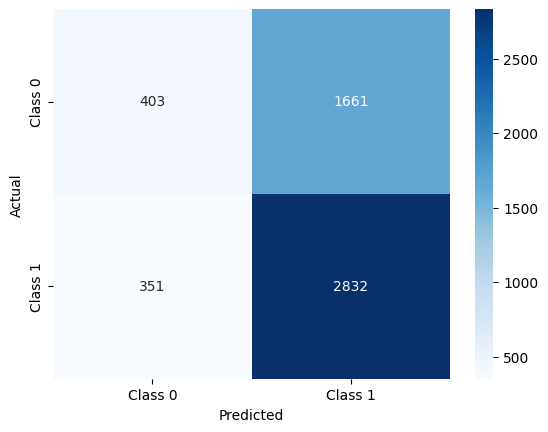

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
from sklearn.metrics import f1_score
print("RF F1:", f1_score(y_test, rf.predict(X_test)))
print("SVM F1:", f1_score(y_test, svm.predict(X_test)))

RF F1: 0.7320295983086681
SVM F1: 0.656308266003729
